In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ssp1_nat_regrowth.Ea8fbc2fc28-F7aa80c14.2025-06-10/run/PA_ssp1_nat_regrowth.Ea8fbc2fc28-F7aa80c14.2025-06-10.sofar.nc'
fates = xr.open_dataset(fates)


In [3]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
#time = fates.variables['time'] / 365.
time = np.arange(0,nyears*12,1) / 12

tave_start = 0
tave_stop = 5*12

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates.variables['fates_levage'][:]

80


Text(0.5, 0, 'Time (years)')

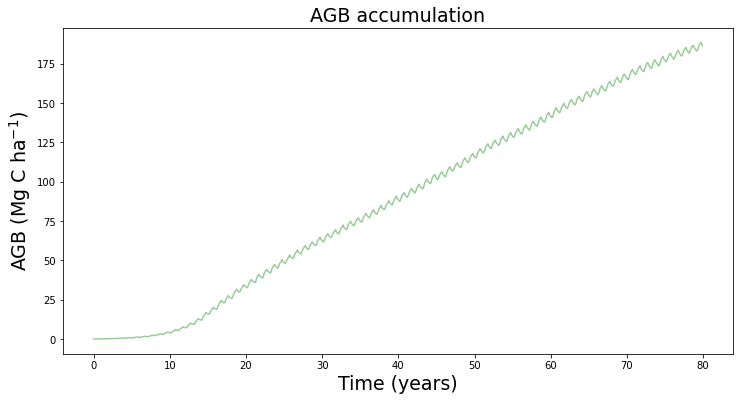

In [4]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, AGB, color='green', label = 'FATES', alpha = 0.4)    
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    


Text(0.02, 0.5, 'Vegc (kg C m-2)')

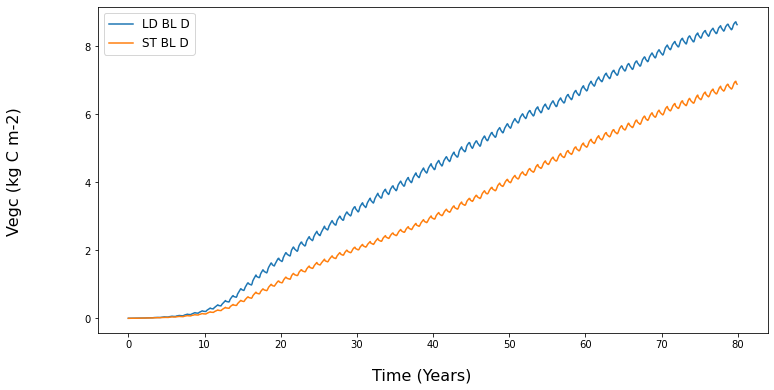

In [6]:
AGB = fates.FATES_VEGC_PF

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(12,6))
axs.plot(time, AGB.isel(fates_levpft=0),label = 'LD BL D')  
axs.plot(time, AGB.isel(fates_levpft=1), label = 'ST BL D')      
axs.legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=16)

###   Soil carbon

Text(0.5, 0, 'Time (years)')

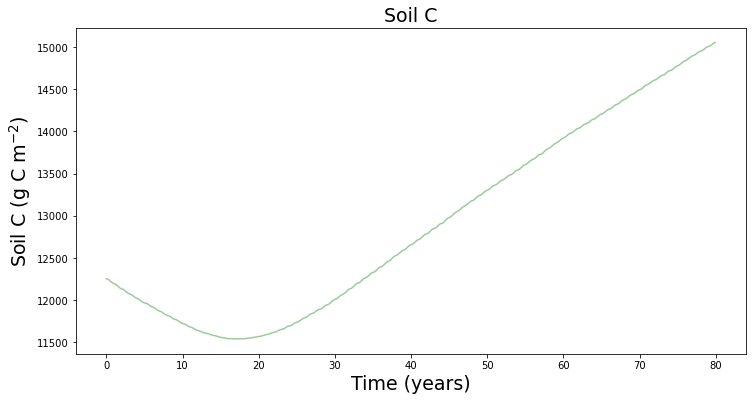

In [7]:
soilC = fates.SOILC 

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, soilC, color='green', label = 'FATES', alpha = 0.4)    
f1ax0.set_title(r'Soil C', fontsize = 19)
f1ax0.set_ylabel(r'Soil C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    

### Sources of mortality 

In [8]:
nplant = fa.scpf_to_scls_by_pft(fates.FATES_NPLANT_SZPF, fates)
nplant = nplant.sum(dim='fates_levpft')

bmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_BACKGROUND_SZPF, fates)
bmort = bmort.sum(dim='fates_levpft')
bmort = bmort/nplant

hmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_HYDRAULIC_SZPF, fates)
hmort = hmort.sum(dim='fates_levpft')
hmort = hmort/nplant

cmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_CSTARV_SZPF, fates)
cmort = cmort.sum(dim='fates_levpft')
cmort = cmort/nplant

tmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_TERMINATION_SZPF, fates)
tmort = tmort.sum(dim='fates_levpft')
tmort = tmort/nplant

fmort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_FREEZING_SZPF, fates)
fmort = fmort.sum(dim='fates_levpft')
fmort = fmort/nplant

imort = fa.scpf_to_scls_by_pft(fates.FATES_MORTALITY_IMPACT_SZPF, fates)
imort = imort.sum(dim='fates_levpft')
imort = imort/nplant


In [9]:
print(bmort.shape)

(960, 1, 17)


(0.0, 10.0)

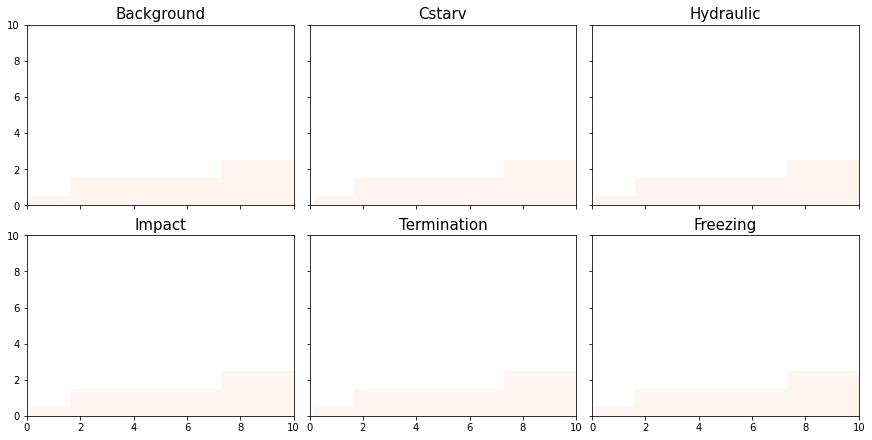

In [10]:
fig1, ((f1ax0,f1ax1,f1ax2),(f1ax3,f1ax4,f1ax5)) = plt.subplots(nrows=2,ncols=3, figsize=(12,6),
                                                              constrained_layout=True,
                                                              sharex=True,sharey=True)

#fig2, ((f2ax0, f2ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(16,5))

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

im = f1ax0.pcolormesh(time, cohort_size_bins, np.squeeze(bmort).transpose(), cmap=cmap, norm=norm)
f1ax0.set_title(r'Background', fontsize=15)
f1ax0.set_xlim(0,10)
f1ax0.set_ylim(0,10)

im = f1ax1.pcolormesh(time, cohort_size_bins, np.squeeze(cmort).transpose(), cmap=cmap, norm=norm)
f1ax1.set_title(r'Cstarv', fontsize=15)
f1ax1.set_xlim(0,10)

im = f1ax2.pcolormesh(time, cohort_size_bins, np.squeeze(hmort).transpose(), cmap=cmap, norm=norm)
f1ax2.set_title(r'Hydraulic', fontsize=15)
f1ax2.set_xlim(0,10)

im = f1ax3.pcolormesh(time, cohort_size_bins, np.squeeze(imort).transpose(), cmap=cmap, norm=norm)
f1ax3.set_title(r'Impact', fontsize=15)
f1ax3.set_xlim(0,10)

im = f1ax4.pcolormesh(time, cohort_size_bins, np.squeeze(tmort).transpose(), cmap=cmap, norm=norm)
f1ax4.set_title(r'Termination', fontsize=15)
f1ax4.set_xlim(0,10)

im = f1ax5.pcolormesh(time, cohort_size_bins, np.squeeze(fmort).transpose(), cmap=cmap, norm=norm)
f1ax5.set_title(r'Freezing', fontsize=15)
f1ax5.set_xlim(0,10)

In [11]:
nplant = fates.FATES_NPLANT_SZPF.sum(dim='fates_levscpf')
hmort = fates.FATES_MORTALITY_HYDRAULIC_SZPF.sum(dim='fates_levscpf')
hmort = hmort/nplant

cmort = fates.FATES_MORTALITY_CSTARV_SZPF.sum(dim='fates_levscpf')
cmort = cmort/nplant

Text(0.5, 0, 'Time (years)')

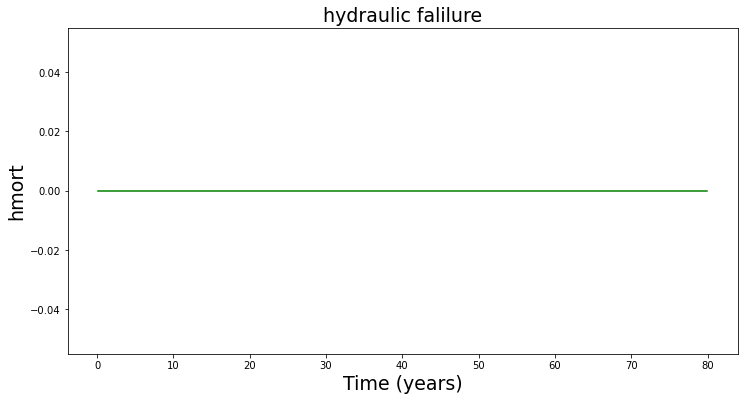

In [12]:

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, hmort, color='green')    
f1ax0.set_title(r'hydraulic falilure', fontsize = 19)
f1ax0.set_ylabel(r'hmort', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    

Text(0.5, 0, 'Time (years)')

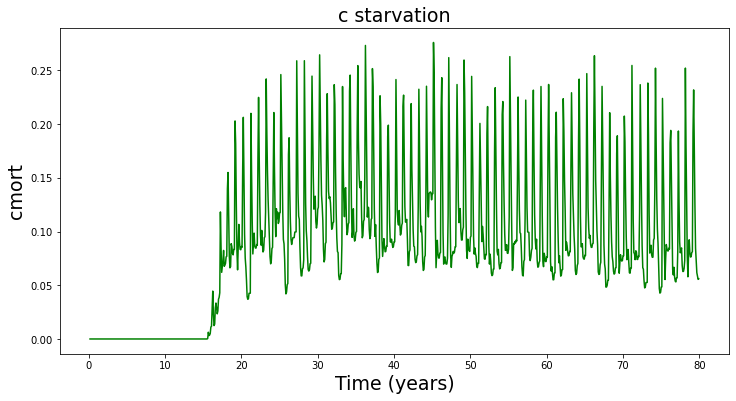

In [13]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, cmort, color='green')    
f1ax0.set_title(r'c starvation', fontsize = 19)
f1ax0.set_ylabel(r'cmort', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    


### Is it a climate problem